# Validate new EDA utility functions
Patterned after `01_eda_initial_explore_2026.ipynb` -- exercises everything new in `eda_utils_basic`, `eda_utils_nlp`, and `eda_utils_sgo`.

In [1]:
import sys
sys.path.append('..')
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils_basic; importlib.reload(eda_utils_basic)
import eda_utils_nlp;   importlib.reload(eda_utils_nlp)
import eda_utils_sgo;   importlib.reload(eda_utils_sgo)

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 200)

In [2]:
%load_ext autoreload
%autoreload 2

## Load data

In [3]:
from pathlib import Path
repo_root = Path.cwd().parents[1]
data_dir = repo_root / 'data' / 'nhtsa'
paths = [
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv',
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv',
]
ads_df = eda_utils_sgo.load_and_concat_csvs(paths)
print(ads_df.shape)

Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software Version - Unk
  ADAS/ADS Software Version CBI
  ADAS/ADS System Version
  ADAS/ADS System Version - Unk
  ADAS/ADS System Version CBI
  ADS Equipped?
  CP Any Air Bags Deployed?
  CP Was Vehicle Towed?
  Federal Reg. Exemption - No
  Federal Reg. Exemption - Unk
  Federal Regulatory Exemption?
  Inv. Officer Email - Unknown
  Inv. Officer Name - Unknown
  Inv. Officer Phone - Unknown
  Investigating Officer Email
  Investigating Officer Name
  Investigating Officer Phone
  Law Enforcement Investigating?
  Lighting
  Mileage
  Mileage - Unknown
  Notice Received Date
  Other Federal Reg. Exemption
  Other Reporting Entities?
  Other Reporting Entities? - NA
  Other Reporting Entities? - Unk
  Posted Speed Limit (MPH)
  Posted Speed Limit - Unknown
  Property Damage?
  Rep Ent Or Mfr Inves

## Basic: missing summary, top values, duplicates

In [4]:
eda_utils_basic.missing_summary(ads_df, top_k=15)

,column,na_share
0,Other Federal Reg. Exemption,0.998077
1,Weather - Other Text,0.998077
2,Federal Regulatory Exemption?,0.991667
3,Source - Other Text,0.988141
4,Investigating Officer Email,0.985256
5,Investigating Officer Phone,0.955449
6,Other Reporting Entities?,0.851923
7,Investigating Officer Name,0.844551
8,Serial Number,0.822115
9,Investigating Agency,0.752564


In [5]:
eda_utils_basic.value_counts_top(ads_df, 'Reporting Entity', top_k=15)

,Reporting Entity,count
0,Waymo LLC,1978
1,Cruise LLC,207
2,"General Motors, LLC",201
3,Transdev Alternative Services,188
4,"Zoox, Inc.",156
5,Avride Inc.,45
6,May Mobility,41
7,Motional,26
8,Ford Motor Company,26
9,Argo AI,26


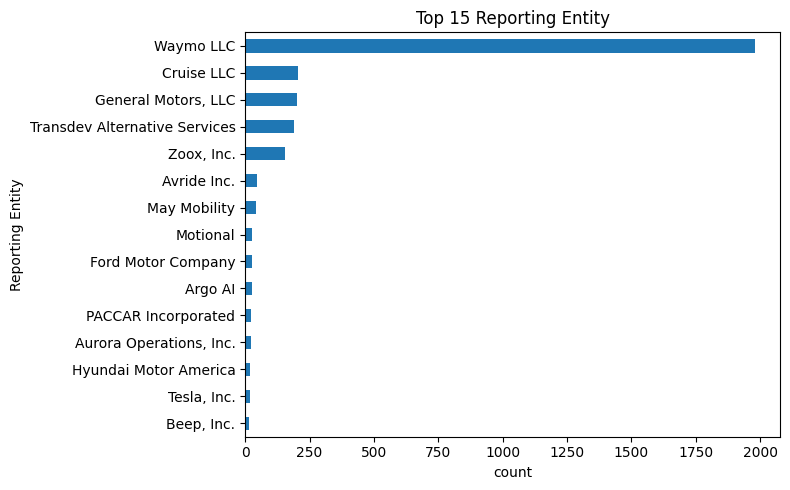

In [6]:
eda_utils_basic.plot_top_values(ads_df, 'Reporting Entity', top_k=15)
plt.show()

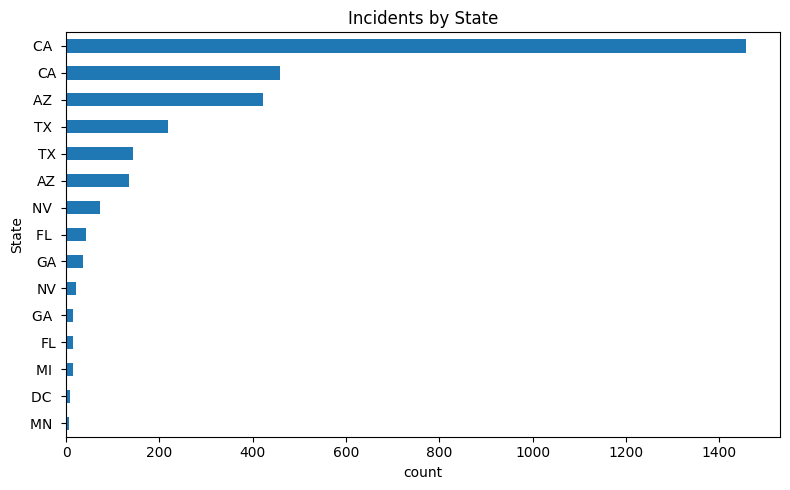

In [7]:
eda_utils_basic.plot_top_values(ads_df, 'State', top_k=15, title='Incidents by State')
plt.show()

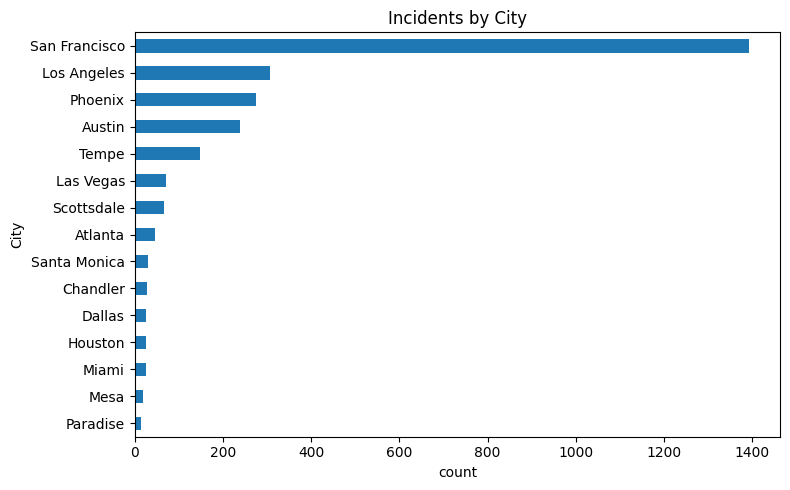

In [8]:
eda_utils_basic.plot_top_values(ads_df, 'City', top_k=15, title='Incidents by City')
plt.show()

In [9]:
dupes, total_rows_in_dupes, n_dupe_ids = eda_utils_basic.duplicates_summary(ads_df, 'Same Incident ID', top_k=15)
print('rows in duplicate ids:', total_rows_in_dupes, ' /  unique dupe ids:', n_dupe_ids)
dupes

rows in duplicate ids: 1329  /  unique dupe ids: 539


,Same Incident ID,count
0,,15
1,8cb088f47f347b4,8
2,aeb0ef282584e35,7
3,62c1ea636449cfd,6
4,7dc63f84ed3a0fb,6
5,d8658d11ce22465,6
6,20699d65c5c18d0,6
7,ce612b3607697d1,5
8,bd4f1d59062450f,5
9,99108ea3e1b8746,5


## Group-by: source x reporting entity, crosstab

In [10]:
eda_utils_basic.group_counts(ads_df, ['Reporting Entity', 'Highest Injury Severity Alleged'], top_k=20)

,Reporting Entity,Highest Injury Severity Alleged,count
0,Waymo LLC,No Injuries Reported,1134
1,Waymo LLC,Property Damage. No Injured Reported,603
2,Transdev Alternative Services,No Injuries Reported,166
3,Cruise LLC,No Injuries Reported,147
4,"General Motors, LLC",No Injuries Reported,140
5,Waymo LLC,Minor,84
6,"Zoox, Inc.",No Injuries Reported,77
7,Waymo LLC,Minor W/O Hospitalization,50
8,Waymo LLC,Unknown,46
9,"Zoox, Inc.",Minor,34


In [11]:
eda_utils_basic.crosstab_pct(ads_df, 'Reporting Entity', 'Highest Injury Severity Alleged').head(20)

Highest Injury Severity Alleged,Fatality,Minor,Minor W/ Hospitalization,Minor W/O Hospitalization,Moderate,Moderate W/ Hospitalization,Moderate W/O Hospitalization,No Injured Reported,No Injuries Reported,Property Damage. No Injured Reported,Serious,Unknown,NaN
Reporting Entity,,,,,,,,,,,,,
Ambarella,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Apollo Autonomous Driving USA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Apple Inc.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Argo AI,0.0,15.4,0.0,0.0,7.7,0.0,0.0,0.0,76.9,0.0,0.0,0.0,0.0
"Aurora Operations, Inc.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.8,81.0,14.3,0.0,0.0,0.0
AutoX Technologies Inc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Avride Inc.,0.0,0.0,2.2,2.2,0.0,0.0,0.0,26.7,6.7,60.0,0.0,0.0,2.2
"Beep, Inc.",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.3,26.7,0.0,0.0,0.0
"Chrysler (FCA US, LLC)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0


## Time: month and hour-of-day

In [12]:
eda_utils_basic.monthly_counts(ads_df, 'Incident Date').tail(15)

C:\Users\james\claude_code_repos\avird-2026-eda-v001\eda\ADS_to_2026_03_16\..\eda_utils_basic.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors='coerce').dt.to_period('M')


,month,count
42,2025-01,89
43,2025-02,99
44,2025-03,87
45,2025-04,106
46,2025-05,119
47,2025-06,78
48,2025-07,69
49,2025-08,63
50,2025-09,68
51,2025-10,100


C:\Users\james\claude_code_repos\avird-2026-eda-v001\eda\ADS_to_2026_03_16\..\eda_utils_basic.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors='coerce').dt.to_period('M')


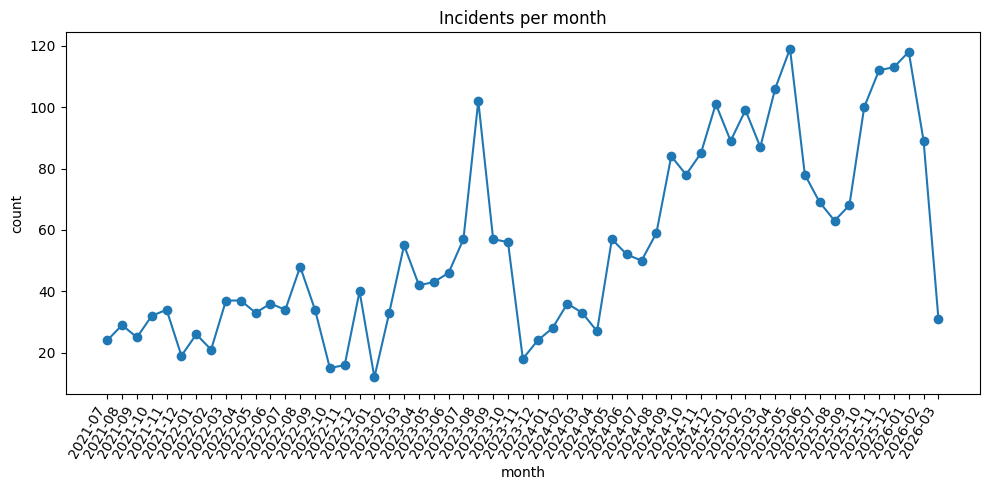

In [13]:
eda_utils_basic.plot_monthly(ads_df, 'Incident Date', title='Incidents per month')
plt.show()

C:\Users\james\claude_code_repos\avird-2026-eda-v001\eda\ADS_to_2026_03_16\..\eda_utils_basic.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(series, errors='coerce').dt.to_period('M')


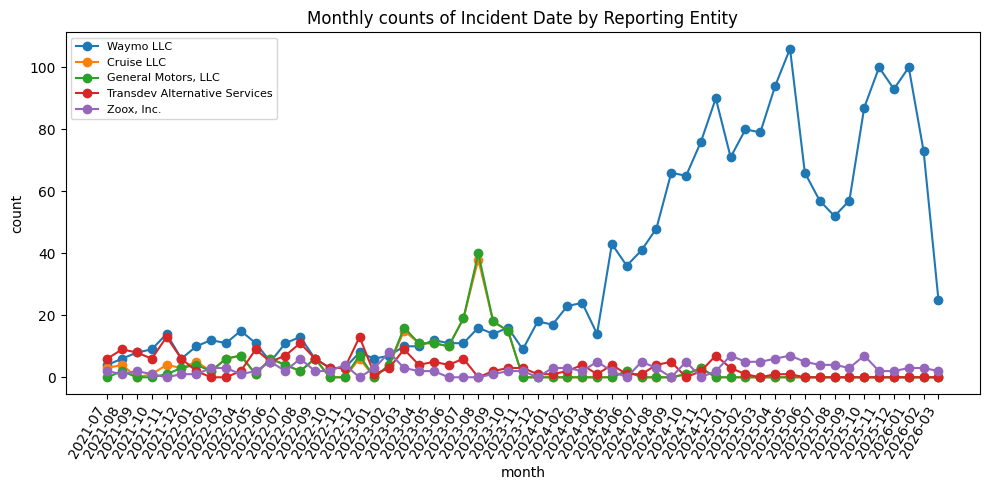

In [14]:
eda_utils_basic.plot_monthly(ads_df, 'Incident Date', group_col='Reporting Entity', top_k_groups=5)
plt.show()

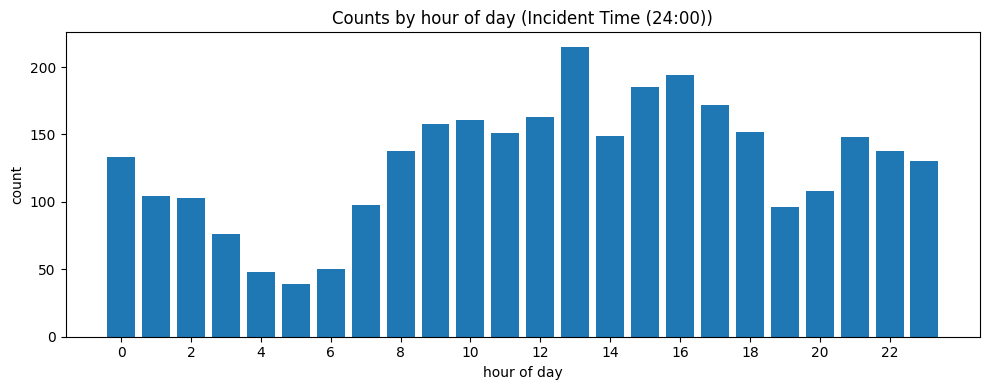

In [15]:
eda_utils_basic.plot_hour_of_day(ads_df, 'Incident Time (24:00)')
plt.show()

In [16]:
eda_utils_basic.night_day_split(ads_df, 'Incident Time (24:00)')

time_bucket
day        2082
night      1027
unknown      11
Name: count, dtype: int64

## SGO: contact areas, data availability, redacted, vehicle stopped, treatment

In [17]:
eda_utils_sgo.summarize_contact_areas(ads_df, 'SV')

,area,count
0,Rear,765
1,Rear Left,739
2,Rear Right,639
3,Front Right,415
4,Front Left,368
5,Front,363
6,Left,276
7,Right,220
8,Bottom,124
9,Unknown,35


In [18]:
eda_utils_sgo.contact_area_compare(ads_df)

,area,SV,CP
0,Rear,765,167
1,Rear Left,739,202
2,Rear Right,639,236
3,Front Right,415,761
4,Front Left,368,545
5,Front,363,768
6,Left,276,266
7,Right,220,410
8,Bottom,124,13
9,Unknown,35,281


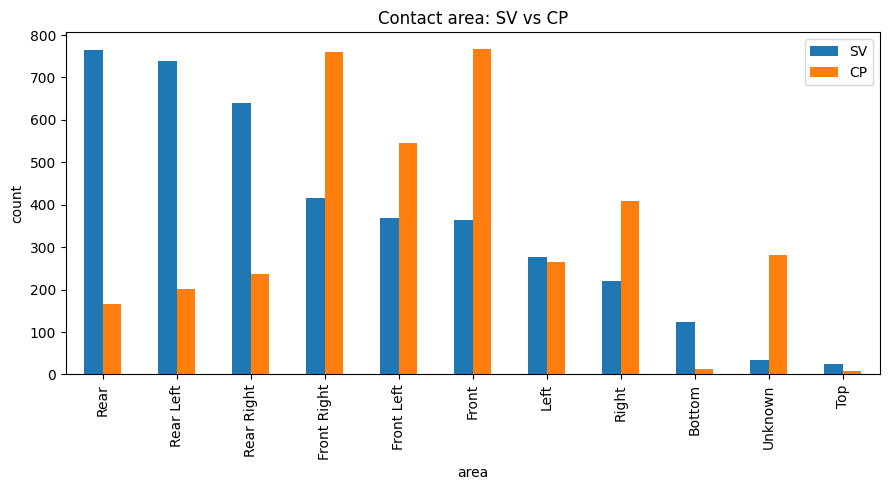

In [19]:
eda_utils_sgo.plot_contact_area_compare(ads_df)
plt.show()

In [20]:
eda_utils_sgo.data_availability_summary(ads_df)

,source,count,share
0,Video,3045,0.976
1,Telematics,2862,0.917
2,Other,1989,0.638
3,EDR,474,0.152
4,Police Rpt,124,0.040
5,Complaints,26,0.008
6,Unknown,19,0.006
7,No Data,3,0.001


In [21]:
overall, by_severity = eda_utils_sgo.vehicle_stopped_analysis(ads_df)
print(overall)
by_severity

           count  share
sv_motion              
stopped     1627  0.521
moving      1456  0.467
unknown       37  0.012


sv_motion,moving,stopped,unknown
Highest Injury Severity Alleged,,,
Fatality,3,2,0
Minor,123,77,2
Minor W/ Hospitalization,11,12,0
Minor W/O Hospitalization,22,37,0
Moderate,26,31,0
Moderate W/ Hospitalization,2,2,0
Moderate W/O Hospitalization,0,1,0
No Injured Reported,37,12,0
No Injuries Reported,860,1031,30


In [22]:
version_cols = [c for c in ads_df.columns if 'Version' in c and 'Unk' not in c and 'CBI' not in c]
print(version_cols)
eda_utils_sgo.redacted_breakdown(ads_df, version_cols, group_col='Reporting Entity', top_k=15)

['Report Version', 'ADAS/ADS System Version', 'ADAS/ADS Hardware Version', 'ADAS/ADS Software Version', 'Automation Feature Version']


,Reporting Entity,column,redacted,total,share
0,Cruise LLC,ADAS/ADS System Version,206,207,0.995
1,Cruise LLC,ADAS/ADS Software Version,112,207,0.541
2,Cruise LLC,ADAS/ADS Hardware Version,111,207,0.536
3,Argo AI,ADAS/ADS System Version,26,26,1.000
4,Ford Motor Company,ADAS/ADS System Version,24,26,0.923
5,"Tesla, Inc.",Automation Feature Version,18,18,1.000
6,PACCAR Incorporated,ADAS/ADS System Version,17,22,0.773
7,Motional,ADAS/ADS System Version,17,26,0.654
8,"Aurora Operations, Inc.",ADAS/ADS System Version,16,21,0.762
9,Motional,ADAS/ADS Hardware Version,14,26,0.538


In [23]:
raw, canonical = eda_utils_sgo.value_counts_for_treatment(ads_df, 'Operating Entity', top_k=20)
print('raw:'); print(raw)
print('\ncanonical:'); print(canonical)

raw:
           Operating Entity   raw
0                 Waymo LLC  2122
1                Cruise LLC   395
2                      Zoox   140
3                   Argo AI    50
4                  Motional    39
5              May Mobility    38
6   Aurora Operations, Inc.    35
7               Avride Inc.    31
8                Waymo LLC.    26
9                 Tesla Inc    18
10                      NaN    17
11                Zoox Inc.    14
12    Kodiak Robotics, Inc.    13
13               Beep, Inc.    11
14                  Pony.ai    11
15                   Cruise    10
16                   WeRide     9
17              Waymo, LLC.     9
18        May Mobility Inc.     7
19              ADMT- VWGoA     6

canonical:
                canonical  canonical_count
0               waymo llc             2164
1              cruise llc              395
2                    zoox              140
3                 argo ai               50
4                motional               39
5          

In [24]:
raw, canonical = eda_utils_sgo.value_counts_for_treatment(ads_df, 'Investigating Agency', top_k=20)
print(canonical)

                              canonical  canonical_count
0                                   NaN             2349
1       san francisco police department              248
2             phoenix police department               85
3               tempe police department               52
4         los angeles police department               43
5              austin police department               31
6          scottsdale police department               20
7               miami police department               17
8             california highway patrol               15
9             houston police department               12
10            atlanta police department               12
11                                 sfpd               11
12           chandler police department                8
13  arizona department of public safety                7
14             dallas police department                7
15          inglewood police department                6
16                   las vegas 

In [25]:
summary, dupe_head = eda_utils_sgo.same_incident_duplicates(ads_df)
print(summary)
dupe_head

   unique_ids  ids_with_dupes  rows_in_dupes
0        2330             539           1329


,Same Incident ID,count
0,,15
1,8cb088f47f347b4,8
2,aeb0ef282584e35,7
3,62c1ea636449cfd,6
4,7dc63f84ed3a0fb,6
5,d8658d11ce22465,6
6,20699d65c5c18d0,6
7,ce612b3607697d1,5
8,bd4f1d59062450f,5
9,99108ea3e1b8746,5


## NLP: word cloud (skipped if `wordcloud` not installed)

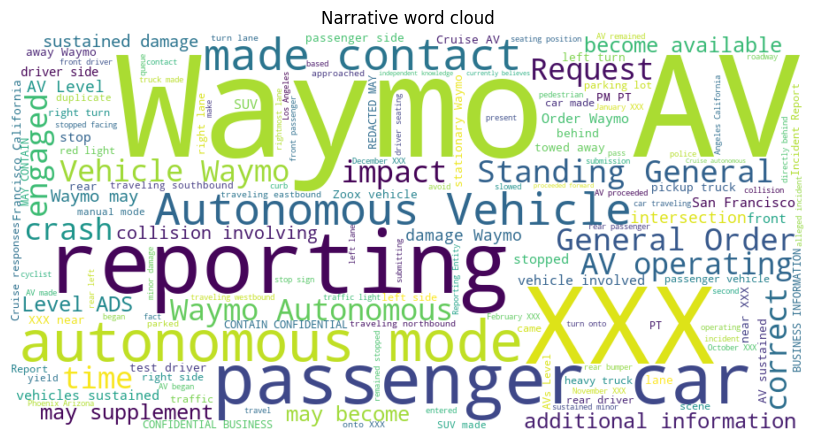

In [26]:
try:
    eda_utils_nlp.plot_word_cloud(ads_df['Narrative'], title='Narrative word cloud')
    plt.show()
except ImportError as e:
    print('skip:', e)